In [1]:
from nichenetpy.utils import (
    read_csv_cols,
    read_csv_rows
)
from nichenetpy.model_construction import (
    construct_weighted_networks,
    apply_hub_correction,
    construct_ligand_target_matrix
)
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import LigandReceptorNetwork
from nichenetpy.wrappers import create_ligand_activity_heatmap
from nichenetpy.parameter_optimization import construct_and_evaluate

import os
import requests
import pandas as pd
import pickle
import json

In [2]:
network_path = os.path.normpath("./tutorial_files/model_construction/human")
if not os.path.exists(network_path):
    os.makedirs(network_path)
for filename in (
    "gr_human.csv",
    "lr_network_human.csv",
    "lr_sig_human.csv",
    "optimized_source_weights.csv"
):
    file_path = os.path.join(network_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14929618/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

In [3]:
with open("D:/Data/nichenetpy/model_optimization/settings_training_f1234.json", "rb") as file:
    settings_CV = json.loads(file.read())
settings = settings_CV["settings"]

In [4]:
gr_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "gr_human.csv")))
lr_network_df = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_network_human.csv")))
sig_network = pd.DataFrame(read_csv_cols(os.path.join(network_path, "lr_sig_human.csv")))

In [5]:
with open("./output/output_nsga2.pkl", "rb") as file:
    output = pickle.loads(file.read())

In [6]:
source_weights = {
    k: float(v)
    for k, v in output["settings_training_f1234"][0].items()
}
lr_sig_hub = source_weights.pop("lr_sig_hub")
gr_hub = source_weights.pop("gr_hub")
ltf_cutoff = source_weights.pop("ltf_cutoff")
damping_factor = source_weights.pop("damping_factor")
weighted_networks = construct_weighted_networks(
    lr_network_df,
    sig_network,
    gr_network,
    source_weights
)
weighted_networks["lr_sig"] = apply_hub_correction(weighted_networks["lr_sig"], hub=lr_sig_hub)
weighted_networks["gr"] = apply_hub_correction(weighted_networks["gr"], hub=gr_hub)

In [7]:
predictor = LigandActivityPredictor(
    *construct_ligand_target_matrix(
        weighted_networks,
        lr_network_df,
        set(lr_network_df["from"]),
        damping_factor=damping_factor,
        ltf_cutoff=ltf_cutoff
    )
)

In [8]:
lr_network = LigandReceptorNetwork(lr_network_df)

In [9]:
data_dir = "D:/Data/nichenetpy/Daniele_data/csv"
ligand_activities_sorted = dict()
for filename in os.listdir(data_dir):
    data = pd.DataFrame(read_csv_cols(os.path.join(data_dir, filename)))
    ligand_activities = predictor.predict_ligand_activities(
        geneset=data[data["is_de"] == "TRUE"][""],
        background_expressed_genes=data[""],
        potential_ligands=lr_network.get_ligands().intersection(data[""])
    )
    ligand_activities_sorted[filename] = sorted(
        ligand_activities.items(),
        key=lambda x : (-x[1]["aupr_corrected"], x[0])
    )

C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pcc = pearsonr(response, prediction).statistic
C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pcc = pearsonr(response, prediction).statistic
C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pcc = pearsonr(response, prediction).statistic
C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pcc = pearsonr(response, prediction).statistic
C:\Users\victorm\Documents\nichenetpy\src\nichenetpy\metrics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is no

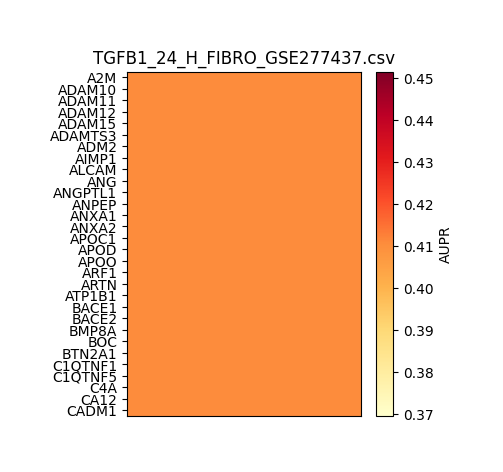

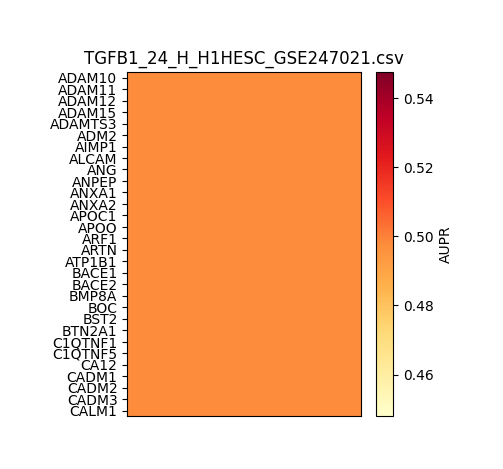

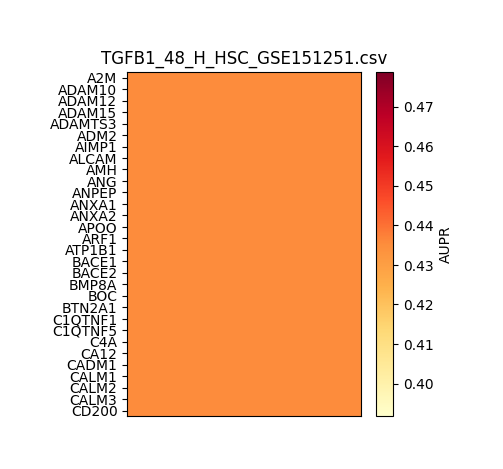

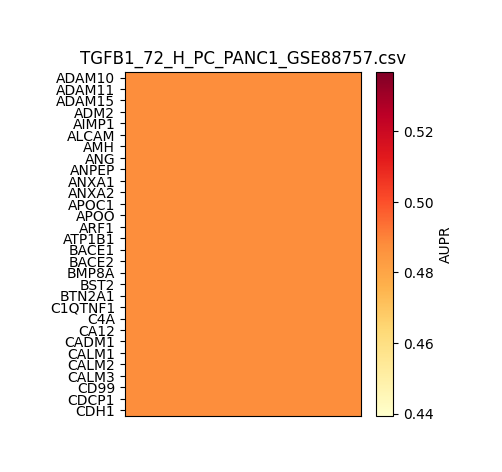

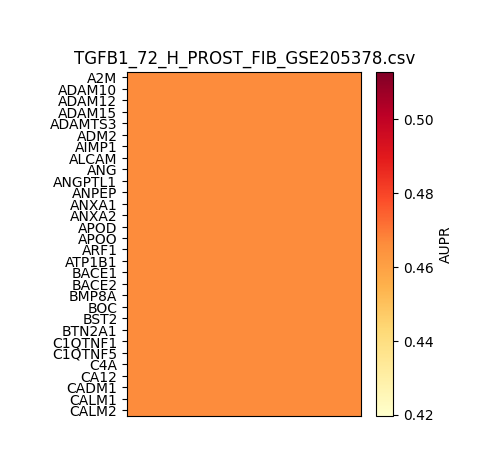

In [10]:
for filename, act in ligand_activities_sorted.items():
    fig, ax = create_ligand_activity_heatmap(
        act[:30],
        figsize=(4, 4)
    )
    ax.set_title(filename)

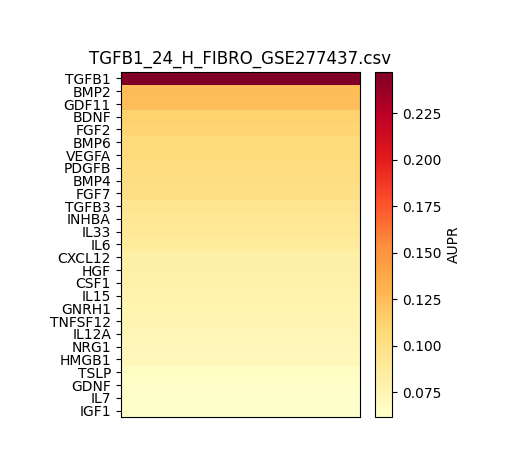

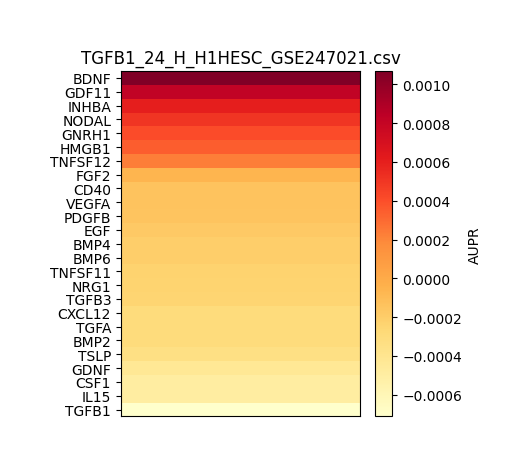

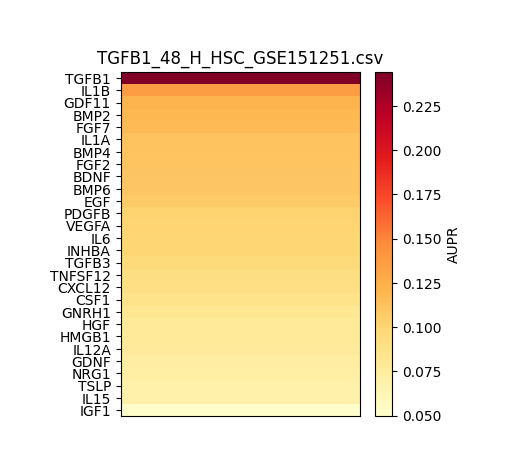

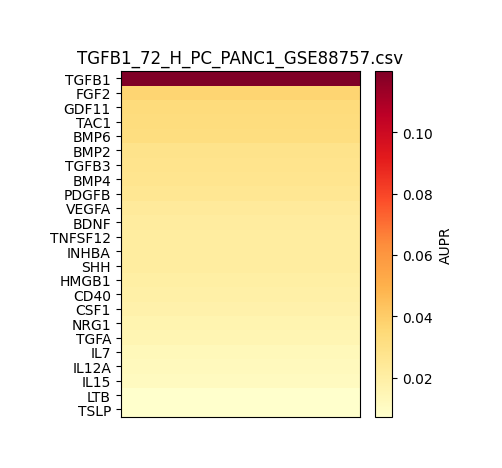

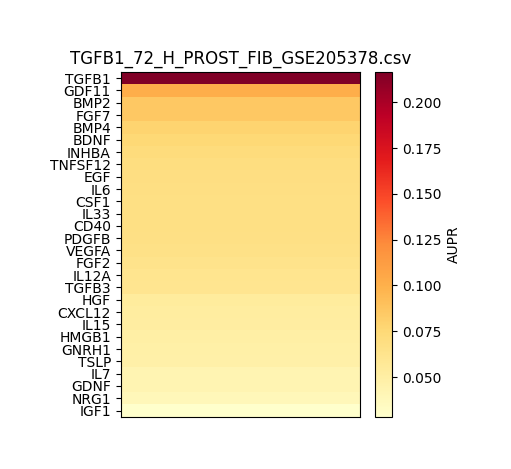

In [11]:
optimized_source_weights = tuple(zip(*read_csv_rows(os.path.join(network_path, "optimized_source_weights.csv"))[1]))
optimized_source_weights = dict(zip(optimized_source_weights[0], [float(e) for e in optimized_source_weights[1]]))
res = construct_and_evaluate(
    optimized_source_weights,
    0.115,
    0.0803,
    0.926,
    0.789,
    lr_network_df,
    gr_network,
    sig_network,
    settings
)
score = res[1:]
weighted_networks = res[0]["weighted networks"]
predictor = LigandActivityPredictor(*res[0]["ligand-target matrix"])
lr_network = LigandReceptorNetwork(lr_network_df)
data_dir = "D:/Data/nichenetpy/Daniele_data/csv"
ligand_activities_sorted = dict()
for filename in os.listdir(data_dir):
    data = pd.DataFrame(read_csv_cols(os.path.join(data_dir, filename)))
    ligand_activities = predictor.predict_ligand_activities(
        geneset=data[data["is_de"] == "TRUE"][""],
        background_expressed_genes=data[""],
        potential_ligands=predictor.get_ligands().intersection(data[""])
    )
    ligand_activities_sorted[filename] = sorted(
        ligand_activities.items(),
        key=lambda x : (-x[1]["aupr_corrected"], x[0])
    )
for filename, act in ligand_activities_sorted.items():
    fig, ax = create_ligand_activity_heatmap(
        act[:30],
        figsize=(4, 4)
    )
    ax.set_title(filename)

In [12]:
score

(np.float64(0.546645675138368), np.float64(0.9740259740259742))